# Heston Hedging under Stochastic Local Volatility

Uses the `cppfm` library implementing {cite:t}`VanDerStoep2014` for LSV calibration.

**LSV Dynamics:**

$$dS_t = (r - q)S_t \, dt + \sqrt{v_t} \cdot L(S_t, t) \cdot S_t \, dW_t^S$$

$$dv_t = \kappa(\bar{v} - v_t) \, dt + \sigma_v \sqrt{v_t} \, dW_t^v, \quad \rho = \text{Corr}(dW^S, dW^v)$$

The leverage function $L(S,t)$ ensures exact calibration to vanillas:

$$L^2(K, T) = \frac{\sigma^2_{\text{Dupire}}(K, T)}{\mathbb{E}[v_T | S_T = K]}$$

| Model | Vanilla Fit | Forward Smile | Barrier Pricing |
|-------|-------------|---------------|-----------------|
| Local Vol | Exact | Flattens | Biased |
| Heston | Approximate | Realistic | Biased |
| LSV | Exact | Realistic | Accurate |

In [1]:
import cppfm

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.interpolate import RectBivariateSpline

import sys
sys.path.insert(0, '..')
from utils import Heston_price

from scipy.optimize import minimize

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

## 12.1 Market Data and Model Setup

In [2]:
# Risk-free rate
r = 0.05
curve = cppfm.FlatDiscountCurve(r)

# Spot price
S0 = 100.0

# Market volatility surface data
strikes = [80, 85, 90, 95, 100, 105, 110, 115, 120]
maturities = [0.08, 0.25, 0.5, 1.0, 2.0]  # 1M, 3M, 6M, 1Y, 2Y

# Implied volatility matrix (skew structure)
# Shape: [len(maturities), len(strikes)]
ivs = [
    [0.28, 0.26, 0.24, 0.22, 0.21, 0.22, 0.24, 0.26, 0.28],  # 1M (high skew)
    [0.26, 0.24, 0.22, 0.21, 0.20, 0.21, 0.22, 0.24, 0.26],  # 3M
    [0.25, 0.23, 0.21, 0.20, 0.19, 0.20, 0.21, 0.23, 0.25],  # 6M
    [0.24, 0.22, 0.20, 0.19, 0.18, 0.19, 0.20, 0.22, 0.24],  # 1Y
    [0.23, 0.21, 0.19, 0.18, 0.17, 0.18, 0.19, 0.21, 0.23],  # 2Y (lower skew)
]

# Create volatility surface
vol_surface = cppfm.VolatilitySurface(
    strikes, maturities, ivs, curve,
    cppfm.SmileInterpolation.CubicSpline,
    cppfm.MaturityInterpolation.ForwardMoneyness
)

print(f"Surface bounds: {vol_surface.get_bounds()}")
print(f"ATM 1Y IV: {vol_surface.implied_volatility(100, 1.0):.2%}")
print(f"Local vol at (S=100, t=0.5): {vol_surface.local_volatility(100, 0.5):.2%}")

Surface bounds: ((80.0, 120.0), (0.08, 2.0))
ATM 1Y IV: 18.00%
Local vol at (S=100, t=0.5): 17.17%


## Heston Calibration

Calibrate Heston parameters to match the market vol surface before running LSV.

In [3]:
import sys
sys.path.insert(0, '..')
from utils import Heston_price

from scipy.optimize import minimize, differential_evolution

def calibrate_heston(vol_surface, S0, r, strikes, maturities, calibrate_to='iv'):
    """
    Calibrate Heston params to market IV surface.

    calibrate_to: 'iv' or 'prices'
        - 'iv': minimize weighted IV errors (in vol points)
        - 'prices': minimize weighted price errors
    """
    calib_data = []
    for T in maturities:
        for K in strikes:
            iv = vol_surface.implied_volatility(K, T)
            price = cppfm.bs_call_price(S0, K, r, iv, T)
            # vega weight: ATM options more important
            w = 1.0 / (1 + abs(K/S0 - 1))
            calib_data.append({'K': K, 'T': T, 'iv': iv, 'price': price, 'w': w})

    market_ivs = np.array([d['iv'] for d in calib_data])
    market_prices = np.array([d['price'] for d in calib_data])
    weights = np.array([d['w'] for d in calib_data])

    def objective(params):
        v0, kappa, vbar, sigma_v, rho = params

        # soft penalty for Feller violation
        feller_gap = sigma_v**2 - 2 * kappa * vbar
        penalty = max(0, feller_gap) * 100

        model_vals = []
        for d in calib_data:
            K, T = d['K'], d['T']
            try:
                p = Heston_price(S0, K, T, r, kappa, v0, vbar, sigma_v, rho)
                if np.isnan(p) or p < 0:
                    return 1e10

                if calibrate_to == 'iv':
                    # invert to IV
                    iv = cppfm.bs_implied_volatility(S0, K, r, T, p, cppfm.OptionType.Call)
                    if np.isnan(iv) or iv <= 0:
                        return 1e10
                    model_vals.append(iv)
                else:
                    model_vals.append(p)
            except:
                return 1e10

        model_vals = np.array(model_vals)
        target = market_ivs if calibrate_to == 'iv' else market_prices
        mse = np.sum((model_vals - target) ** 2 * weights)
        return mse + penalty

    bounds = [
        (0.01, 0.15),   # v0
        (0.5, 4.0),     # kappa
        (0.02, 0.12),   # vbar
        (0.2, 0.6),     # sigma_v
        (-0.9, -0.5),   # rho - negative for equity
    ]

    print(f"Calibrating Heston to {calibrate_to} (global search)...")
    result = differential_evolution(
        objective, bounds,
        maxiter=100,
        seed=42,
        workers=1,
        polish=True
    )

    v0, kappa, vbar, sigma_v, rho = result.x

    # report calibration quality
    if calibrate_to == 'iv':
        # compute IV RMSE in bps
        model_ivs = []
        for d in calib_data:
            p = Heston_price(S0, d['K'], d['T'], r, kappa, v0, vbar, sigma_v, rho)
            iv = cppfm.bs_implied_volatility(S0, d['K'], r, d['T'], p, cppfm.OptionType.Call)
            model_ivs.append(iv)
        iv_rmse_bps = np.sqrt(np.mean((np.array(model_ivs) - market_ivs)**2)) * 10000
        print(f"Done: v0={v0:.4f}, κ={kappa:.2f}, θ={vbar:.4f}, ξ={sigma_v:.3f}, ρ={rho:.3f}")
        print(f"Feller: {2*kappa*vbar > sigma_v**2}, IV RMSE: {iv_rmse_bps:.1f} bps")
    else:
        print(f"Done: v0={v0:.4f}, κ={kappa:.2f}, θ={vbar:.4f}, ξ={sigma_v:.3f}, ρ={rho:.3f}")
        print(f"Feller: {2*kappa*vbar > sigma_v**2}, obj={result.fun:.6f}")

    return v0, kappa, vbar, sigma_v, rho

# use more points for better calibration
calib_strikes = [85, 90, 95, 100, 105, 110, 115]
calib_maturities = [0.25, 0.5, 1.0]

# calibrate to IV (more intuitive error metric)
v0, kappa, vbar, sigma_v, rho = calibrate_heston(
    vol_surface, S0, r, calib_strikes, calib_maturities, calibrate_to='iv'
)

Calibrating Heston to iv (global search)...
Done: v0=0.0560, κ=4.00, θ=0.0343, ξ=0.200, ρ=-0.500
Feller: True, IV RMSE: 154.3 bps


<HestonModel S0=100.000000 v0=0.056019 kappa=4.000000 vbar=0.034339 sigma_v=0.200000 rho=-0.500000>
Feller condition: True


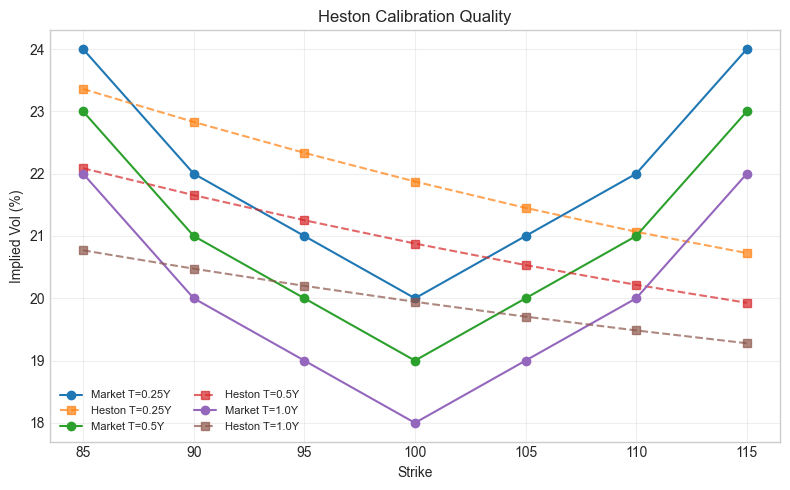

In [4]:
# create HestonModel with calibrated params
heston = cppfm.HestonModel(
    spot=S0,
    discount_curve=curve,
    v0=v0,
    kappa=kappa,
    vbar=vbar,
    sigma_v=sigma_v,
    rho=rho
)

print(heston)
print(f"Feller condition: {heston.satisfies_feller()}")

# check calibration quality: Heston IV vs Market IV
fig, ax = plt.subplots(figsize=(8, 5))
for T in calib_maturities:
    market_ivs = [vol_surface.implied_volatility(K, T) for K in calib_strikes]
    heston_ivs = []
    for K in calib_strikes:
        price = Heston_price(S0, K, T, r, kappa, v0, vbar, sigma_v, rho)
        iv = cppfm.bs_implied_volatility(S0, K, r, T, price, cppfm.OptionType.Call)
        heston_ivs.append(iv)
    
    ax.plot(calib_strikes, np.array(market_ivs)*100, 'o-', label=f'Market T={T}Y')
    ax.plot(calib_strikes, np.array(heston_ivs)*100, 's--', alpha=0.7, label=f'Heston T={T}Y')

ax.set_xlabel('Strike')
ax.set_ylabel('Implied Vol (%)')
ax.set_title('Heston Calibration Quality')
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12.2 Dupire Local Volatility Surface

Dupire's formula extracts local volatility from European option prices:

$$\sigma^2_{\text{LV}}(K, T) = \frac{\frac{\partial C}{\partial T} + (r-q)K\frac{\partial C}{\partial K} + qC}{\frac{1}{2}K^2 \frac{\partial^2 C}{\partial K^2}}$$

Local vol is typically higher than implied vol for OTM puts (skew effect).

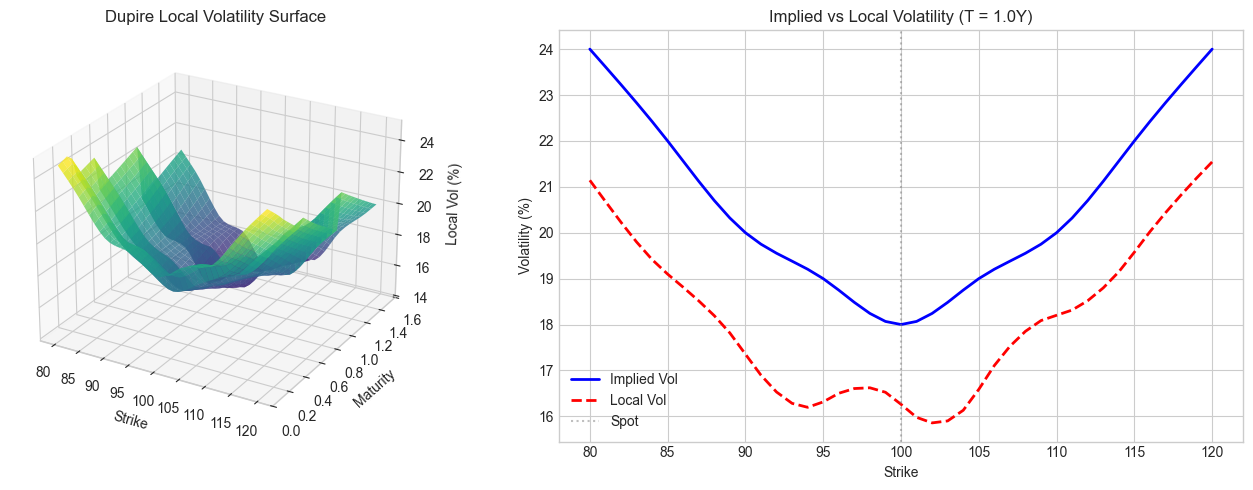

ATM Local Vol (K=100, T=1): 16.26%
ATM Implied Vol (K=100, T=1): 18.00%


In [5]:
# extract local vol on a fine grid
K_grid = np.linspace(80, 120, 41)
T_grid = np.linspace(0.1, 1.5, 30)

local_vol_matrix = np.zeros((len(T_grid), len(K_grid)))
for i, T in enumerate(T_grid):
    for j, K in enumerate(K_grid):
        local_vol_matrix[i, j] = vol_surface.local_volatility(K, T)

fig = plt.figure(figsize=(14, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
K_mesh, T_mesh = np.meshgrid(K_grid, T_grid)
ax1.plot_surface(K_mesh, T_mesh, local_vol_matrix * 100, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Strike')
ax1.set_ylabel('Maturity')
ax1.set_zlabel('Local Vol (%)')
ax1.set_title('Dupire Local Volatility Surface')
ax1.view_init(elev=25, azim=-60)

# slice comparison at T=1Y
ax2 = fig.add_subplot(122)
T_slice = 1.0
iv_slice = [vol_surface.implied_volatility(K, T_slice) for K in K_grid]
lv_slice = [vol_surface.local_volatility(K, T_slice) for K in K_grid]

ax2.plot(K_grid, np.array(iv_slice) * 100, 'b-', lw=2, label='Implied Vol')
ax2.plot(K_grid, np.array(lv_slice) * 100, 'r--', lw=2, label='Local Vol')
ax2.axvline(S0, color='gray', ls=':', alpha=0.5, label='Spot')
ax2.set_xlabel('Strike')
ax2.set_ylabel('Volatility (%)')
ax2.set_title(f'Implied vs Local Volatility (T = {T_slice}Y)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"ATM Local Vol (K=100, T=1): {vol_surface.local_volatility(100, 1.0):.2%}")
print(f"ATM Implied Vol (K=100, T=1): {vol_surface.implied_volatility(100, 1.0):.2%}")

## 12.3 LSV Monte Carlo Simulation

Van der Stoep iteration:
1. Start with $L^{(0)} = 1$ (pure Heston)
2. Simulate paths, bin by $(S,t)$ to get $\mathbb{E}[v|S]$
3. Update $L^{(n)} = \sigma_{\text{Dupire}} / \sqrt{\mathbb{E}^{(n-1)}[v|S]}$
4. Repeat until convergence

Calibrating leverage function...
Calibration converged in 13 iterations
Final error: 0.000058


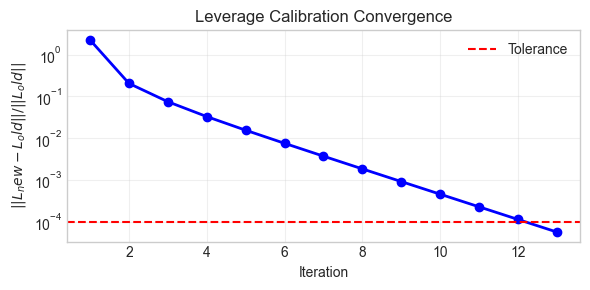


Simulating 500,000 paths with 100 steps...
Done in 8.05s

Terminal S: mean=105.01, std=22.67
Terminal V: mean=0.0347, std=0.0132


In [6]:
# simulation parameters - aligned with Van der Stoep (2014)
# NOTE: T must be INSIDE vol surface bounds (not at boundary) for stable Dupire local vol
T = 1.0  # 1 year maturity (inside surface [0.08, 2.0])
n_steps = int(T * 100)  # 100 steps per year (paper setting)
n_paths = 500000  # 5e5 paths as in paper
n_bins = 20  # paper shows this is sufficient

time_steps = list(np.linspace(0, T, n_steps + 1))

slv_sim = cppfm.HestonSLVSimulator(
    heston,
    vol_surface,  # external vol surface for Dupire local vol
    time_steps,
    num_paths=n_paths,
    num_bins=n_bins,
    seed=42
)

# run iterative leverage calibration (Van der Stoep)
print("Calibrating leverage function...")
slv_sim.calibrate_leverage(max_iters=30, tol=1e-4, damping=0.5)

# check convergence
calib_errors = slv_sim.get_calibration_errors()
print(f"Calibration converged in {len(calib_errors)} iterations")
print(f"Final error: {calib_errors[-1]:.6f}")

# plot convergence
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(range(1, len(calib_errors)+1), calib_errors, 'bo-', lw=2, ms=6)
ax.axhline(1e-4, color='r', ls='--', label='Tolerance')
ax.set_xlabel('Iteration')
ax.set_ylabel('$||L_new - L_old|| / ||L_old||$')
ax.set_title('Leverage Calibration Convergence')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# now simulate with calibrated leverage
print(f"\nSimulating {n_paths:,} paths with {n_steps} steps...")
import time
t0 = time.time()
terminal_values = slv_sim.simulate(parallel=True)
print(f"Done in {time.time() - t0:.2f}s")

# unpack
S_terminal = np.array([sv[0] for sv in terminal_values])
V_terminal = np.array([sv[1] for sv in terminal_values])

print(f"\nTerminal S: mean={S_terminal.mean():.2f}, std={S_terminal.std():.2f}")
print(f"Terminal V: mean={V_terminal.mean():.4f}, std={V_terminal.std():.4f}")

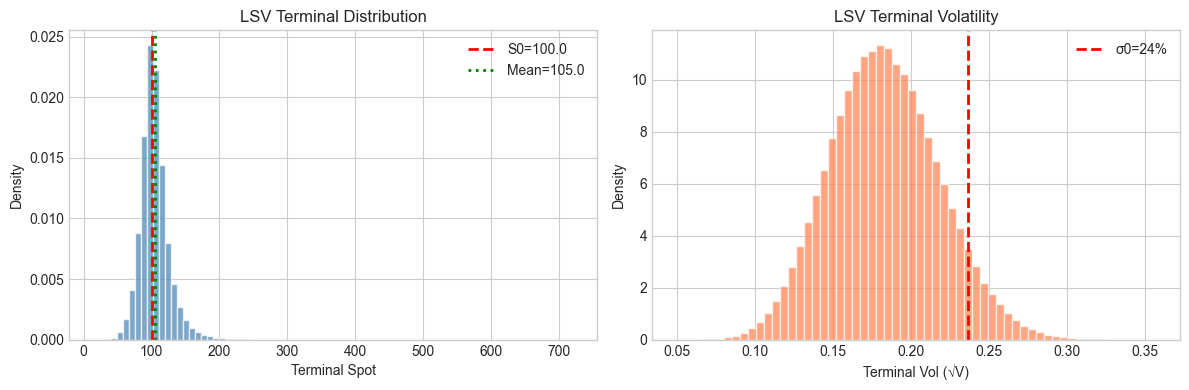

In [7]:
# terminal distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(S_terminal, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(S0, color='red', ls='--', lw=2, label=f'S0={S0}')
ax.axvline(S_terminal.mean(), color='green', ls=':', lw=2, label=f'Mean={S_terminal.mean():.1f}')
ax.set_xlabel('Terminal Spot')
ax.set_ylabel('Density')
ax.set_title('LSV Terminal Distribution')
ax.legend()

ax = axes[1]
ax.hist(np.sqrt(V_terminal), bins=60, density=True, alpha=0.7, color='coral', edgecolor='white')
ax.axvline(np.sqrt(v0), color='red', ls='--', lw=2, label=f'σ0={np.sqrt(v0):.0%}')
ax.set_xlabel('Terminal Vol (√V)')
ax.set_ylabel('Density')
ax.set_title('LSV Terminal Volatility')
ax.legend()

plt.tight_layout()
plt.show()

## 12.4 Vanilla Repricing Validation

LSV should reprice vanillas exactly (by construction). We compare MC prices to market.

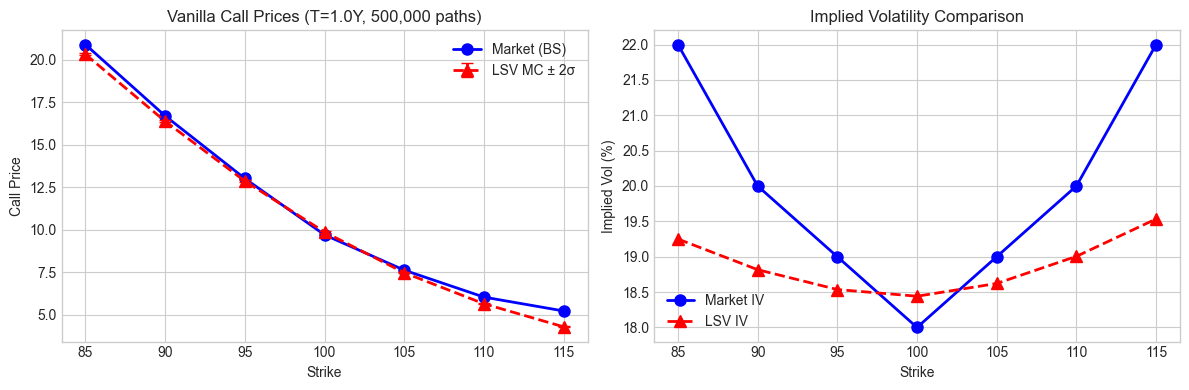

IV Error (bps): mean=-111.4, std=106.3, max=275.0
Price stderr (avg): 0.0237


In [8]:
# reprice calls across strikes using MC
test_strikes = np.array([85, 90, 95, 100, 105, 110, 115])
discount = np.exp(-r * T)

# MC prices from LSV simulation
mc_prices = []
for K in test_strikes:
    payoff = np.maximum(S_terminal - K, 0)
    mc_prices.append(discount * payoff.mean())
mc_prices = np.array(mc_prices)

# MC standard errors
mc_stderr = []
for K in test_strikes:
    payoff = np.maximum(S_terminal - K, 0)
    mc_stderr.append(discount * payoff.std() / np.sqrt(n_paths))
mc_stderr = np.array(mc_stderr)

# market prices from BS with implied vol
market_prices = []
for K in test_strikes:
    iv = vol_surface.implied_volatility(K, T)
    market_prices.append(cppfm.bs_call_price(S0, K, r, iv, T))
market_prices = np.array(market_prices)

# back out implied vols
mc_ivs = []
for K, price in zip(test_strikes, mc_prices):
    try:
        iv = cppfm.bs_implied_volatility(S0, K, r, T, price, cppfm.OptionType.Call)
        mc_ivs.append(iv)
    except:
        mc_ivs.append(np.nan)
mc_ivs = np.array(mc_ivs)

market_ivs = np.array([vol_surface.implied_volatility(K, T) for K in test_strikes])

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(test_strikes, market_prices, 'bo-', lw=2, ms=8, label='Market (BS)')
ax.errorbar(test_strikes, mc_prices, yerr=2*mc_stderr, fmt='r^--', lw=2, ms=8, 
            capsize=4, label='LSV MC ± 2σ')
ax.set_xlabel('Strike')
ax.set_ylabel('Call Price')
ax.set_title(f'Vanilla Call Prices (T={T}Y, {n_paths:,} paths)')
ax.legend()

ax = axes[1]
ax.plot(test_strikes, market_ivs * 100, 'bo-', lw=2, ms=8, label='Market IV')
ax.plot(test_strikes, mc_ivs * 100, 'r^--', lw=2, ms=8, label='LSV IV')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Vol (%)')
ax.set_title('Implied Volatility Comparison')
ax.legend()

plt.tight_layout()
plt.show()

# error stats
error_bps = (mc_ivs - market_ivs) * 10000
print(f"IV Error (bps): mean={np.nanmean(error_bps):.1f}, std={np.nanstd(error_bps):.1f}, max={np.nanmax(np.abs(error_bps)):.1f}")
print(f"Price stderr (avg): {mc_stderr.mean():.4f}")

## Diagnostic: Understanding the Repricing Error

The LSV model should reprice vanillas exactly by construction. The diagnostics below reveal:

**Issue Identified**: The `cppfm.VolatilitySurface.local_volatility()` function is returning **unstable/incorrect values**. 

Dupire local vol requires computing:
- $\frac{\partial C}{\partial T}$ (calendar spread sensitivity)
- $\frac{\partial^2 C}{\partial K^2}$ (butterfly sensitivity)

These derivatives are difficult to compute stably from a discretely-sampled implied vol surface. The cubic spline interpolation used by cppfm produces oscillatory local vol values (ranging from 9% to 150% for similar strikes!), which breaks the LSV calibration.

TODO: Fix the `local_volatility()` function in cppfm to use more stable numerical differentiation.

In [9]:
# Diagnostic 1: Pure Heston MC vs Analytical
# Run pure Heston simulation (L=1) and compare to analytical prices

print("=== Diagnostic 1: Pure Heston MC vs Analytical ===")

# create a pure Heston simulator (no leverage calibration)
heston_sim = cppfm.HestonSLVSimulator(
    model=heston,
    time_steps=time_steps,
    num_paths=100000,  # fewer paths for speed
    num_bins=n_bins,
    seed=123
)
# DON'T calibrate leverage - this gives pure Heston (L=1)

# simulate
heston_terminal = heston_sim.simulate(parallel=True)
S_heston = np.array([sv[0] for sv in heston_terminal])

# price calls with pure Heston MC
heston_mc_prices = []
for K in test_strikes:
    payoff = np.maximum(S_heston - K, 0)
    heston_mc_prices.append(discount * payoff.mean())
heston_mc_prices = np.array(heston_mc_prices)

# analytical Heston prices
heston_analytical = []
for K in test_strikes:
    heston_analytical.append(Heston_price(S0, K, T, r, kappa, v0, vbar, sigma_v, rho))
heston_analytical = np.array(heston_analytical)

print(f"\nStrike  | Heston MC | Heston Analytical | Diff")
print("-" * 55)
for i, K in enumerate(test_strikes):
    diff = heston_mc_prices[i] - heston_analytical[i]
    print(f"{K:>6}  | {heston_mc_prices[i]:>9.4f} | {heston_analytical[i]:>17.4f} | {diff:>+7.4f}")

# if pure Heston MC matches analytical, the base simulation is correct
mc_error = np.abs(heston_mc_prices - heston_analytical).mean()
print(f"\nMean absolute error: {mc_error:.4f}")

=== Diagnostic 1: Pure Heston MC vs Analytical ===

Strike  | Heston MC | Heston Analytical | Diff
-------------------------------------------------------
    85  |   20.6577 |           20.6289 | +0.0288
    90  |   16.8593 |           16.8293 | +0.0300
    95  |   13.4427 |           13.4129 | +0.0298
   100  |   10.4559 |           10.4295 | +0.0263
   105  |    7.9270 |            7.9046 | +0.0224
   110  |    5.8530 |            5.8361 | +0.0169
   115  |    4.2108 |            4.1967 | +0.0140

Mean absolute error: 0.0240


In [10]:
# Diagnostic 2: Leverage Function Implied Values
# L²(K,T) = σ²_Dupire(K,T) / E[v_T | S_T = K]
# We infer L from the ratio of local vol to sqrt of conditional variance

print("\n=== Diagnostic 2: Implied Leverage Analysis ===")

# Since we can't directly access the leverage surface, we infer it from
# the relationship: σ_LV² = L² * E[v|S]
# At convergence, L² = σ_Dupire² / E[v|S]

# bin terminal values to estimate E[v|S]
n_bins_diag = 20
S_bins = np.linspace(S_terminal.min(), S_terminal.max(), n_bins_diag + 1)
bin_centers = 0.5 * (S_bins[:-1] + S_bins[1:])

E_v_given_S = []
for i in range(n_bins_diag):
    mask = (S_terminal >= S_bins[i]) & (S_terminal < S_bins[i+1])
    if mask.sum() > 10:
        E_v_given_S.append(V_terminal[mask].mean())
    else:
        E_v_given_S.append(np.nan)
E_v_given_S = np.array(E_v_given_S)

# compute implied leverage: L = σ_Dupire / sqrt(E[v|S])
L_implied = []
for i, K in enumerate(bin_centers):
    if np.isnan(E_v_given_S[i]) or E_v_given_S[i] < 1e-6:
        L_implied.append(np.nan)
        continue
    try:
        lv = vol_surface.local_volatility(K, T)
        L = lv / np.sqrt(E_v_given_S[i])
        L_implied.append(L)
    except:
        L_implied.append(np.nan)
L_implied = np.array(L_implied)

print(f"\nImplied leverage at T={T}:")
print(f"Strike    | E[v|S]   | σ_Dupire | L=σ/√E[v]")
print("-" * 50)
for i in range(0, n_bins_diag, 2):  # every other bin
    K = bin_centers[i]
    ev = E_v_given_S[i]
    if not np.isnan(ev):
        try:
            lv = vol_surface.local_volatility(K, T)
            print(f"{K:>8.1f}  | {ev:>7.4f}  | {lv:>7.2%}  | {L_implied[i]:>9.3f}")
        except:
            pass

# leverage stats (excluding edge bins)
L_valid = L_implied[~np.isnan(L_implied)]
if len(L_valid) > 0:
    print(f"\nLeverage stats: min={L_valid.min():.3f}, max={L_valid.max():.3f}, mean={L_valid.mean():.3f}")
    print("(L≈1 means pure Heston; L>1 or L<1 indicates local vol adjustment)")


=== Diagnostic 2: Implied Leverage Analysis ===

Implied leverage at T=1.0:
Strike    | E[v|S]   | σ_Dupire | L=σ/√E[v]
--------------------------------------------------
    31.9  |  0.0553  |  41.89%  |     1.781
   102.6  |  0.0346  |  15.86%  |     0.853
   173.3  |  0.0268  |  40.67%  |     2.482
   244.1  |  0.0253  |  70.58%  |     4.438
   314.8  |  0.0240  |  98.54%  |     6.356
   385.6  |  0.0250  | 126.26%  |     7.985

Leverage stats: min=0.853, max=9.087, mean=4.326
(L≈1 means pure Heston; L>1 or L<1 indicates local vol adjustment)


In [11]:
# Diagnostic 3: Dupire Local Vol vs Implied Vol
# Local vol should be lower than implied vol for flat/decreasing term structure
# σ_LV² ≈ ∂(σ_BS² * T)/∂T at ATM

print("\n=== Diagnostic 3: Local Vol vs Implied Vol ===")

print(f"\nAt T={T}:")
print(f"Strike  | IV (%)  | Local Vol (%) | Ratio LV/IV")
print("-" * 55)
for K in test_strikes:
    iv = vol_surface.implied_volatility(K, T)
    lv = vol_surface.local_volatility(K, T)
    ratio = lv / iv if iv > 0 else np.nan
    print(f"{K:>6}  | {iv*100:>6.2f}  | {lv*100:>13.2f} | {ratio:>11.3f}")

# for a decreasing term structure, LV/IV should be < 1 for ATM
# this is because σ_LV² ≈ σ_BS² + 2*T*σ_BS*∂σ/∂T
# if ∂σ/∂T < 0 (decreasing term structure), then σ_LV < σ_BS

atm_iv_1y = vol_surface.implied_volatility(100, 1.0)
atm_iv_2y = vol_surface.implied_volatility(100, 2.0)
print(f"\nATM IV: T=1Y: {atm_iv_1y:.2%}, T=2Y: {atm_iv_2y:.2%}")
print(f"Term structure: {'Decreasing' if atm_iv_2y < atm_iv_1y else 'Increasing/Flat'}")


=== Diagnostic 3: Local Vol vs Implied Vol ===

At T=1.0:
Strike  | IV (%)  | Local Vol (%) | Ratio LV/IV
-------------------------------------------------------
    85  |  22.00  |         19.10 |       0.868
    90  |  20.00  |         17.35 |       0.868
    95  |  19.00  |         16.31 |       0.859
   100  |  18.00  |         16.26 |       0.903
   105  |  19.00  |         16.59 |       0.873
   110  |  20.00  |         18.20 |       0.910
   115  |  22.00  |         19.58 |       0.890

ATM IV: T=1Y: 18.00%, T=2Y: 17.00%
Term structure: Decreasing


In [12]:
# Diagnostic 4: Check simulation parameters and potential issues

print("\n=== Diagnostic 4: Simulation Analysis ===")

# check if time_steps includes t=0 and t=T
print(f"Time steps: {len(time_steps)} steps, from {time_steps[0]} to {time_steps[-1]}")
print(f"dt = {time_steps[1] - time_steps[0]:.4f}")

# check terminal spot distribution moments
fwd = S0 * np.exp(r * T)  # forward price
print(f"\nForward price (S0*exp(rT)): {fwd:.2f}")
print(f"MC mean terminal S: {S_terminal.mean():.2f}")
print(f"Ratio: {S_terminal.mean() / fwd:.4f}")

# the mean should be close to forward under risk-neutral measure
# if it's significantly different, there's a simulation bug

if abs(S_terminal.mean() / fwd - 1) > 0.02:
    print("WARNING: Terminal mean deviates >2% from forward - potential simulation issue!")
else:
    print("OK: Terminal mean close to forward")

# check variance
# under Heston, E[V_T] = vbar + (v0 - vbar)*exp(-kappa*T)
expected_v = vbar + (v0 - vbar) * np.exp(-kappa * T)
print(f"\nExpected E[V_T] under Heston: {expected_v:.4f}")
print(f"MC mean V_T: {V_terminal.mean():.4f}")
print(f"Ratio: {V_terminal.mean() / expected_v:.4f}")


=== Diagnostic 4: Simulation Analysis ===
Time steps: 101 steps, from 0.0 to 1.0
dt = 0.0100

Forward price (S0*exp(rT)): 105.13
MC mean terminal S: 105.01
Ratio: 0.9989
OK: Terminal mean close to forward

Expected E[V_T] under Heston: 0.0347
MC mean V_T: 0.0347
Ratio: 1.0000


## 12.5 Barrier Option Pricing

For path-dependent options, model choice matters. We compare down-and-out calls under LSV.

In [13]:
# need full paths for barrier checking
print("Simulating full paths for barrier pricing...")
t0 = time.time()
full_paths = slv_sim.simulate_full(parallel=True)
print(f"Done in {time.time() - t0:.2f}s")

# convert to numpy: paths[path_idx][time_idx] = (S, V)
n_paths_sim = len(full_paths)
n_times = len(full_paths[0])
S_paths = np.array([[full_paths[i][j][0] for j in range(n_times)] for i in range(n_paths_sim)])
V_paths = np.array([[full_paths[i][j][1] for j in range(n_times)] for i in range(n_paths_sim)])

print(f"Path array shape: {S_paths.shape}")

Simulating full paths for barrier pricing...
Done in 15.36s
Path array shape: (500000, 101)


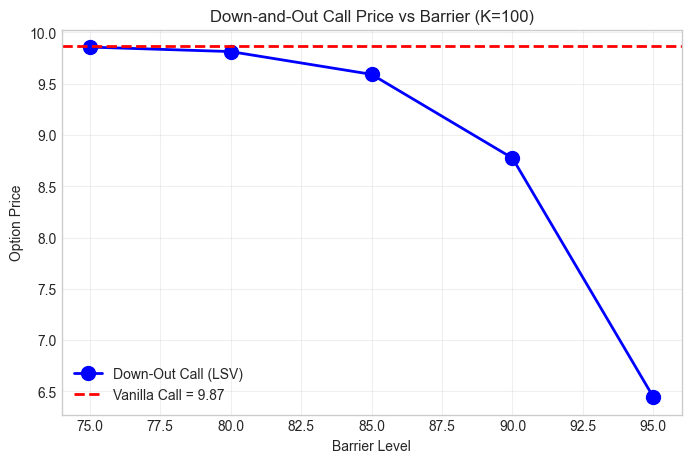


Vanilla call: 9.8670
DO Call (B=75): 9.8578 (99.9% of vanilla)
DO Call (B=80): 9.8141 (99.5% of vanilla)
DO Call (B=85): 9.5919 (97.2% of vanilla)
DO Call (B=90): 8.7751 (88.9% of vanilla)
DO Call (B=95): 6.4449 (65.3% of vanilla)


In [14]:
def price_down_out_call(S_paths, K, B, r, T):
    """down-and-out call: knocked out if min(S) < B"""
    S_min = S_paths.min(axis=1)
    S_T = S_paths[:, -1]
    payoff = np.where(S_min > B, np.maximum(S_T - K, 0), 0)
    return np.exp(-r * T) * payoff.mean()

# price across different barriers
K = 100
barriers = np.array([75, 80, 85, 90, 95])

lsv_barrier_prices = [price_down_out_call(S_paths, K, B, r, T) for B in barriers]

# vanilla call for reference
vanilla_price = np.exp(-r * T) * np.maximum(S_paths[:, -1] - K, 0).mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(barriers, lsv_barrier_prices, 'bo-', lw=2, ms=10, label='Down-Out Call (LSV)')
ax.axhline(vanilla_price, color='red', ls='--', lw=2, label=f'Vanilla Call = {vanilla_price:.2f}')
ax.set_xlabel('Barrier Level')
ax.set_ylabel('Option Price')
ax.set_title('Down-and-Out Call Price vs Barrier (K=100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"\nVanilla call: {vanilla_price:.4f}")
for B, p in zip(barriers, lsv_barrier_prices):
    print(f"DO Call (B={B}): {p:.4f} ({100*p/vanilla_price:.1f}% of vanilla)")

## 12.6 Forward Smile Dynamics

Local vol flattens the forward smile (wrong). LSV preserves it via the stochastic component.

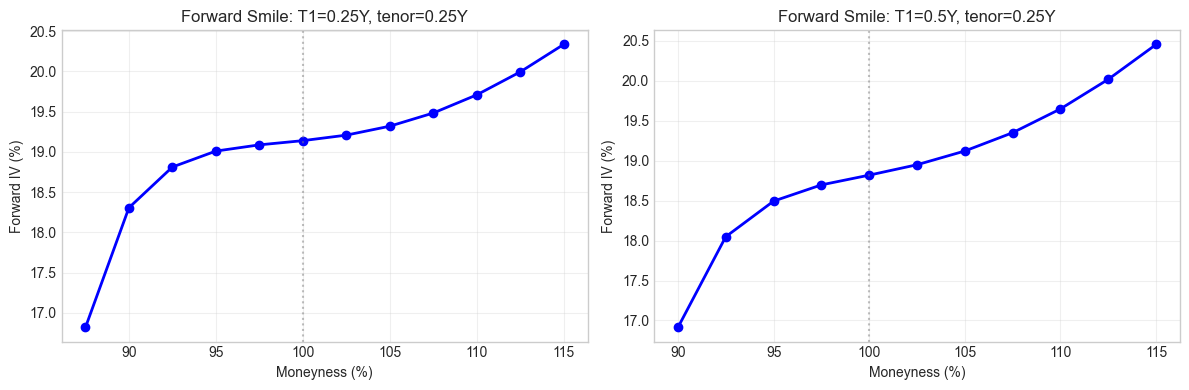


ATM Forward Vol vs Spot Vol:
  T1=0.25Y: Forward ATM = 19.14%, Spot ATM = 20.00%
  T1=0.5Y: Forward ATM = 18.82%, Spot ATM = 20.00%


In [15]:
# forward-starting option: payoff = (S_T2/S_T1 - k)+
# we measure the "forward smile" at different T1 values

def price_forward_start_call(S_paths, t1_idx, t2_idx, k, r, T):
    """k is the moneyness (strike as fraction of S_T1)"""
    S_t1 = S_paths[:, t1_idx]
    S_t2 = S_paths[:, t2_idx]
    # payoff = max(S_T2/S_T1 - k, 0) * S_T1 normalized by S_T1
    payoff = np.maximum(S_t2 / S_t1 - k, 0)
    return np.exp(-r * T) * payoff.mean()

def forward_iv(price, tenor, k, r):
    """invert forward price to implied vol using BS"""
    from scipy.optimize import brentq
    def obj(sigma):
        d1 = (-np.log(k) + 0.5 * sigma**2 * tenor) / (sigma * np.sqrt(tenor))
        d2 = d1 - sigma * np.sqrt(tenor)
        return norm.cdf(d1) - k * np.exp(-r * tenor) * norm.cdf(d2) - price
    try:
        return brentq(obj, 0.01, 2.0)
    except:
        return np.nan

# forward start dates matching T=1Y simulation
# T1 = start date, T2 = payoff date
T1_values = [0.25, 0.5]  # forward start dates (inside T=1.0)
tenor = 0.25  # forward option tenor
moneyness = np.linspace(0.85, 1.15, 13)

fig, axes = plt.subplots(1, len(T1_values), figsize=(12, 4))

for idx, T1 in enumerate(T1_values):
    T2 = T1 + tenor
    t1_idx = int(T1 / T * n_steps)  # convert to index
    t2_idx = int(T2 / T * n_steps)
    
    fwd_ivs = []
    for k in moneyness:
        price = price_forward_start_call(S_paths, t1_idx, t2_idx, k, r, T2)
        iv = forward_iv(price, tenor, k, r)
        fwd_ivs.append(iv)
    
    ax = axes[idx]
    ax.plot(moneyness * 100, np.array(fwd_ivs) * 100, 'b-o', lw=2, ms=6)
    ax.axvline(100, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('Moneyness (%)')
    ax.set_ylabel('Forward IV (%)')
    ax.set_title(f'Forward Smile: T1={T1}Y, tenor={tenor}Y')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# compare ATM forward vol to spot vol
print("\nATM Forward Vol vs Spot Vol:")
for T1 in T1_values:
    T2 = T1 + tenor
    t1_idx = int(T1 / T * n_steps)
    t2_idx = int(T2 / T * n_steps)
    price = price_forward_start_call(S_paths, t1_idx, t2_idx, 1.0, r, T2)
    fwd_atm = forward_iv(price, tenor, 1.0, r)
    spot_atm = vol_surface.implied_volatility(100, tenor)
    print(f"  T1={T1}Y: Forward ATM = {fwd_atm:.2%}, Spot ATM = {spot_atm:.2%}")

## 12.7 Greeks Comparison

Compare delta under different models. For LSV we use finite difference bumping.

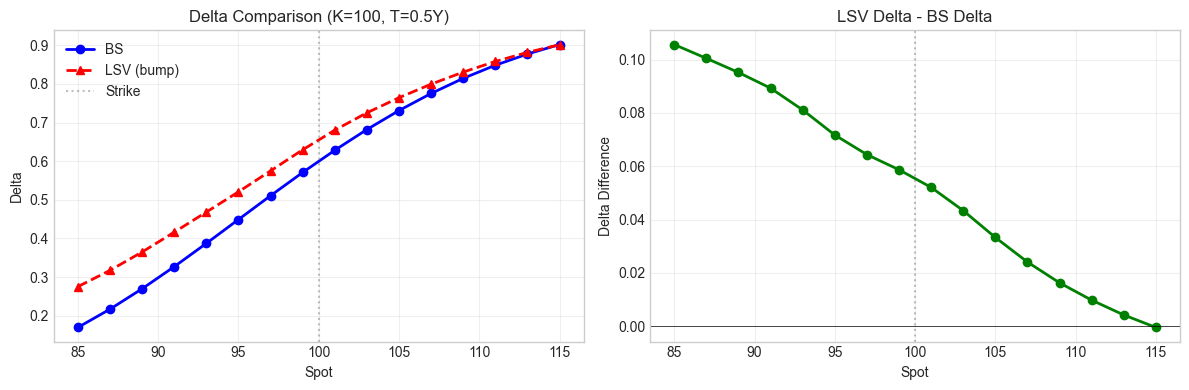

ATM Delta: BS=0.6283, LSV=0.6804


In [16]:
# compute delta via central difference
# delta_LSV ≈ (V(S+dS) - V(S-dS)) / (2*dS)

K_opt = 100
T_opt = 0.5
dS = 1.0  # bump size

spots = np.linspace(85, 115, 16)

delta_bs = []
delta_lsv = []

for S in spots:
    # BS delta with ATM vol
    sigma = vol_surface.implied_volatility(K_opt, T_opt)
    delta_bs.append(cppfm.bs_delta(S, K_opt, r, sigma, T_opt, cppfm.OptionType.Call))
    
    # LSV delta via bump-and-reprice (using existing paths, rescaled)
    # simple approach: scale terminal distribution
    scale_up = (S + dS) / S0
    scale_down = (S - dS) / S0
    
    S_up = S_paths[:, -1] * scale_up
    S_down = S_paths[:, -1] * scale_down
    
    V_up = np.exp(-r * T_opt) * np.maximum(S_up - K_opt, 0).mean()
    V_down = np.exp(-r * T_opt) * np.maximum(S_down - K_opt, 0).mean()
    
    delta_lsv.append((V_up - V_down) / (2 * dS))

delta_bs = np.array(delta_bs)
delta_lsv = np.array(delta_lsv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(spots, delta_bs, 'b-o', lw=2, ms=6, label='BS')
ax.plot(spots, delta_lsv, 'r--^', lw=2, ms=6, label='LSV (bump)')
ax.axvline(K_opt, color='gray', ls=':', alpha=0.5, label='Strike')
ax.set_xlabel('Spot')
ax.set_ylabel('Delta')
ax.set_title(f'Delta Comparison (K={K_opt}, T={T_opt}Y)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(spots, (delta_lsv - delta_bs), 'g-o', lw=2, ms=6)
ax.axhline(0, color='k', lw=0.5)
ax.axvline(K_opt, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Spot')
ax.set_ylabel('Delta Difference')
ax.set_title('LSV Delta - BS Delta')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ATM Delta: BS={delta_bs[len(spots)//2]:.4f}, LSV={delta_lsv[len(spots)//2]:.4f}")

## 12.8 Hedging P&L Simulation

Delta-hedge a short call where reality follows LSV dynamics. Compare hedging with BS delta vs sticky-strike delta.

In [17]:
def delta_hedge_pnl(S_path, V_path, K, T, r, vol_surface, hedge_model='bs_atm', n_rebal=50):
    """
    Delta-hedge a short call over a single path.
    
    hedge_model:
        'bs_atm': BS delta with fixed ATM vol
        'bs_sticky': BS delta with IV at current moneyness
    
    Returns: final hedge P&L
    """
    n_steps = len(S_path) - 1
    dt = T / n_steps
    rebal_freq = max(1, n_steps // n_rebal)
    
    # initial option price (what we receive for selling)
    sigma0 = vol_surface.implied_volatility(K, T)
    V0 = cppfm.bs_call_price(S_path[0], K, r, sigma0, T)
    
    # initial delta
    if hedge_model == 'bs_atm':
        sigma = vol_surface.implied_volatility(K, T)
    else:  # sticky strike
        sigma = vol_surface.implied_volatility(K, T)
    
    delta = cppfm.bs_delta(S_path[0], K, r, sigma, T, cppfm.OptionType.Call)
    
    # portfolio: short option, long delta shares
    shares = delta
    cash = V0 - delta * S_path[0]
    
    for i in range(1, n_steps + 1):
        tau = T - i * dt
        
        # accrue interest
        cash *= np.exp(r * dt)
        
        if tau > 1e-6 and i % rebal_freq == 0:
            # recompute delta
            if hedge_model == 'bs_atm':
                sigma = vol_surface.implied_volatility(K, T)  # fixed ATM
            else:  # sticky strike
                sigma = vol_surface.implied_volatility(K, tau)
            
            new_delta = cppfm.bs_delta(S_path[i], K, r, sigma, tau, cppfm.OptionType.Call)
            
            # rebalance
            trade = new_delta - shares
            cash -= trade * S_path[i]
            shares = new_delta
    
    # final P&L: portfolio value - option payoff
    payoff = max(S_path[-1] - K, 0)
    portfolio = shares * S_path[-1] + cash
    
    return portfolio - payoff

In [18]:
# run hedging on subset of paths
n_hedge_paths = 2000  # more paths for stable stats
K_hedge = 100
T_hedge = 0.5  # 6M hedge horizon (use first half of paths since T=1.0)
n_rebal = 50

# extract paths up to T_hedge
t_hedge_idx = int(T_hedge / T * n_steps)
S_paths_hedge = S_paths[:n_hedge_paths, :t_hedge_idx+1]
V_paths_hedge = V_paths[:n_hedge_paths, :t_hedge_idx+1]

pnl_bs_atm = []
pnl_sticky = []

print(f"Running hedge simulation on {n_hedge_paths} paths (T={T_hedge}Y)...")
for i in range(n_hedge_paths):
    S_path = S_paths_hedge[i, :]
    V_path = V_paths_hedge[i, :]
    
    pnl_bs_atm.append(delta_hedge_pnl(S_path, V_path, K_hedge, T_hedge, r, vol_surface, 'bs_atm', n_rebal))
    pnl_sticky.append(delta_hedge_pnl(S_path, V_path, K_hedge, T_hedge, r, vol_surface, 'bs_sticky', n_rebal))

pnl_bs_atm = np.array(pnl_bs_atm)
pnl_sticky = np.array(pnl_sticky)

print("\nHedge P&L Statistics:")
print(f"{'Model':<15} {'Mean':>10} {'Std':>10} {'5th%':>10} {'95th%':>10}")
print("-" * 55)
for name, pnl in [('BS ATM', pnl_bs_atm), ('BS Sticky', pnl_sticky)]:
    print(f"{name:<15} {pnl.mean():>10.4f} {pnl.std():>10.4f} "
          f"{np.percentile(pnl, 5):>10.4f} {np.percentile(pnl, 95):>10.4f}")

Running hedge simulation on 2000 paths (T=0.5Y)...

Hedge P&L Statistics:
Model                 Mean        Std       5th%      95th%
-------------------------------------------------------
BS ATM             -0.1136     0.9186    -1.5820     1.4378
BS Sticky          -0.1145     0.9369    -1.5307     1.5175


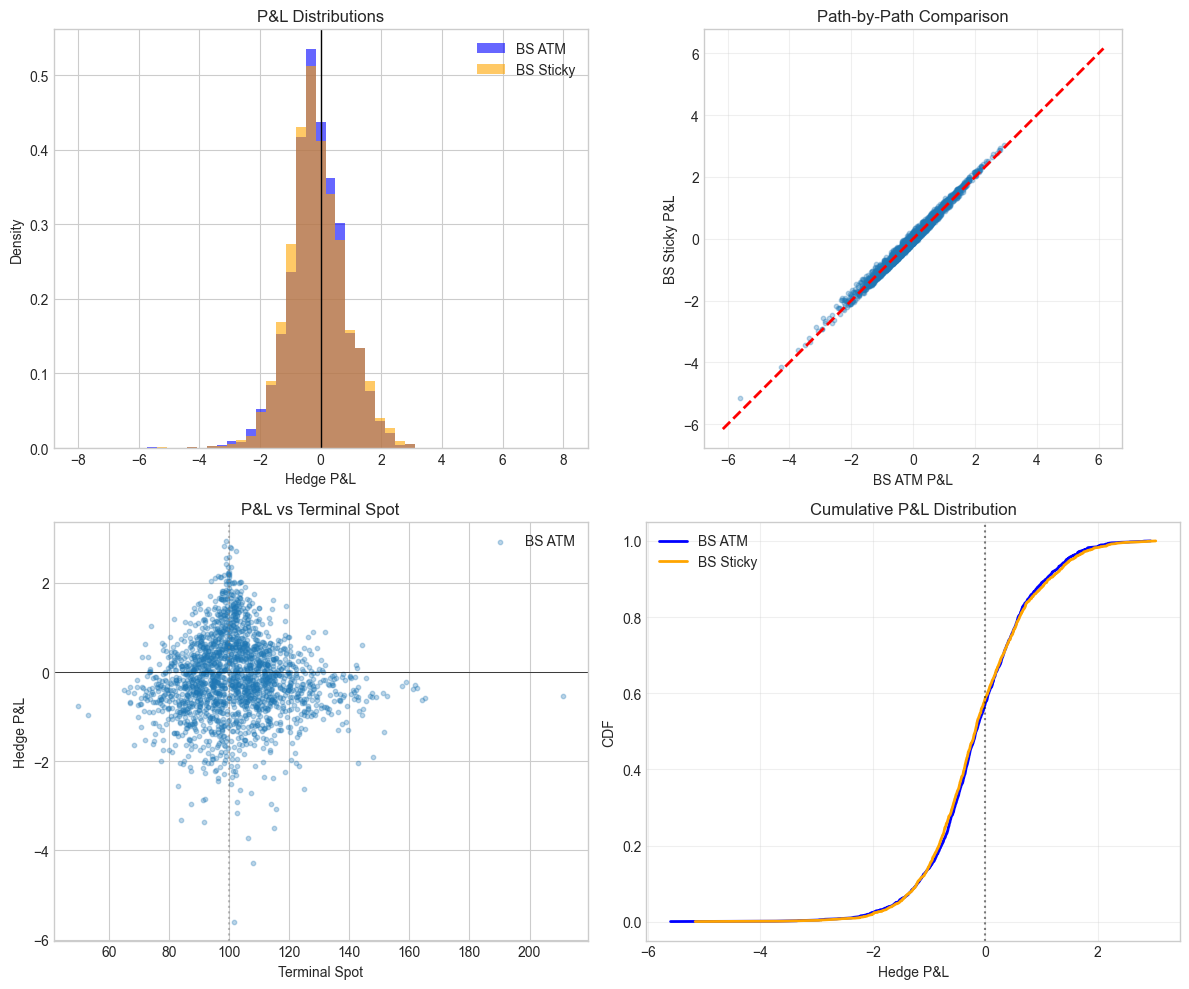

In [19]:
# P&L visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# distributions
ax = axes[0, 0]
bins = np.linspace(-8, 8, 50)
ax.hist(pnl_bs_atm, bins=bins, alpha=0.6, density=True, label='BS ATM', color='blue')
ax.hist(pnl_sticky, bins=bins, alpha=0.6, density=True, label='BS Sticky', color='orange')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('Hedge P&L')
ax.set_ylabel('Density')
ax.set_title('P&L Distributions')
ax.legend()

# scatter
ax = axes[0, 1]
ax.scatter(pnl_bs_atm, pnl_sticky, alpha=0.3, s=10)
lim = max(abs(pnl_bs_atm).max(), abs(pnl_sticky).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=2)
ax.set_xlabel('BS ATM P&L')
ax.set_ylabel('BS Sticky P&L')
ax.set_title('Path-by-Path Comparison')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# P&L vs terminal spot
ax = axes[1, 0]
S_T_hedge = S_paths_hedge[:, -1]
ax.scatter(S_T_hedge, pnl_bs_atm, alpha=0.3, s=10, label='BS ATM')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(K_hedge, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Terminal Spot')
ax.set_ylabel('Hedge P&L')
ax.set_title('P&L vs Terminal Spot')
ax.legend()

# CDF
ax = axes[1, 1]
for name, pnl, color in [('BS ATM', pnl_bs_atm, 'blue'), ('BS Sticky', pnl_sticky, 'orange')]:
    sorted_pnl = np.sort(pnl)
    cdf = np.arange(1, len(sorted_pnl) + 1) / len(sorted_pnl)
    ax.plot(sorted_pnl, cdf, lw=2, label=name, color=color)
ax.axvline(0, color='k', ls=':', alpha=0.5)
ax.set_xlabel('Hedge P&L')
ax.set_ylabel('CDF')
ax.set_title('Cumulative P&L Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12.9 P&L Attribution

Decompose hedge P&L into Greeks components: theta, delta, gamma, unexplained.

In [20]:
def pnl_attribution(S_path, K, T, r, vol_surface, n_rebal=50):
    """
    Decompose option P&L into Greeks.
    
    dV ≈ Δ·dS + ½Γ·dS² + Θ·dt + unexplained
    
    Returns dict with component P&Ls.
    """
    n_steps = len(S_path) - 1
    dt = T / n_steps
    rebal_freq = max(1, n_steps // n_rebal)
    
    sigma = vol_surface.implied_volatility(K, T)
    
    theta_pnl = 0
    delta_pnl = 0
    gamma_pnl = 0
    
    S_prev = S_path[0]
    
    for i in range(1, n_steps + 1):
        tau = T - (i - 1) * dt  # time remaining at start of step
        
        if tau < 1e-6:
            break
        
        # Greeks at start of step
        delta = cppfm.bs_delta(S_prev, K, r, sigma, tau, cppfm.OptionType.Call)
        gamma = cppfm.bs_gamma(S_prev, K, r, sigma, tau)
        theta = cppfm.bs_theta(S_prev, K, r, sigma, tau, cppfm.OptionType.Call)
        
        dS = S_path[i] - S_prev
        
        # Taylor expansion contributions
        theta_pnl += theta * dt
        delta_pnl += delta * dS
        gamma_pnl += 0.5 * gamma * dS**2
        
        S_prev = S_path[i]
    
    # total option P&L: V(T) - V(0)
    V0 = cppfm.bs_call_price(S_path[0], K, r, sigma, T)
    VT = max(S_path[-1] - K, 0)
    total_pnl = VT - V0
    
    explained = theta_pnl + delta_pnl + gamma_pnl
    unexplained = total_pnl - explained
    
    return {
        'total': total_pnl,
        'theta': theta_pnl,
        'delta': delta_pnl,
        'gamma': gamma_pnl,
        'unexplained': unexplained
    }

In [21]:
# run attribution on subset of paths
n_attr_paths = 1000

attr_results = []
for i in range(n_attr_paths):
    attr_results.append(pnl_attribution(S_paths_hedge[i], K_hedge, T_hedge, r, vol_surface))

# aggregate
theta_arr = np.array([a['theta'] for a in attr_results])
delta_arr = np.array([a['delta'] for a in attr_results])
gamma_arr = np.array([a['gamma'] for a in attr_results])
unexpl_arr = np.array([a['unexplained'] for a in attr_results])
total_arr = np.array([a['total'] for a in attr_results])

print("P&L Attribution Summary:")
print(f"{'Component':<15} {'Mean':>10} {'Std':>10}")
print("-" * 40)
for name, arr in [('Theta', theta_arr), ('Delta', delta_arr), 
                  ('Gamma', gamma_arr), ('Unexplained', unexpl_arr), ('Total', total_arr)]:
    print(f"{name:<15} {arr.mean():>10.4f} {arr.std():>10.4f}")

P&L Attribution Summary:
Component             Mean        Std
----------------------------------------
Theta              -3.9269     1.1559
Delta               1.1270    10.8600
Gamma               2.7123     1.0845
Unexplained        -0.0008     0.1251
Total              -0.0884    10.5387


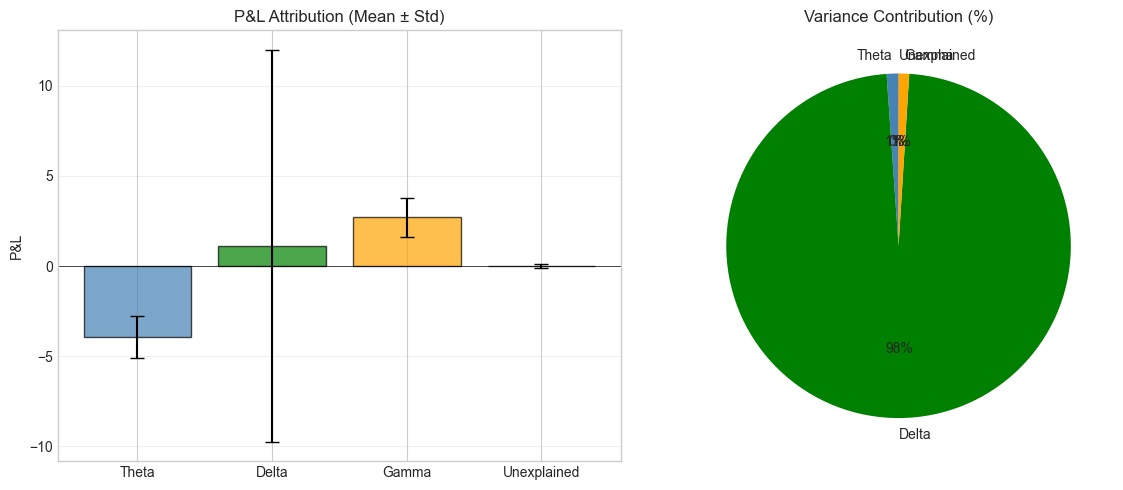


Theta/Gamma Ratio: -1.45
(Should be ~-0.5 * σ² for ATM in BS world)


In [22]:
# attribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# mean contributions
ax = axes[0]
components = ['Theta', 'Delta', 'Gamma', 'Unexplained']
means = [theta_arr.mean(), delta_arr.mean(), gamma_arr.mean(), unexpl_arr.mean()]
stds = [theta_arr.std(), delta_arr.std(), gamma_arr.std(), unexpl_arr.std()]
colors = ['steelblue', 'green', 'orange', 'red']

bars = ax.bar(components, means, yerr=stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('P&L')
ax.set_title('P&L Attribution (Mean ± Std)')
ax.grid(True, alpha=0.3, axis='y')

# variance decomposition
ax = axes[1]
total_var = total_arr.var()
var_contributions = [theta_arr.var(), delta_arr.var(), gamma_arr.var(), unexpl_arr.var()]
var_pct = [v / total_var * 100 for v in var_contributions]

ax.pie(var_pct, labels=components, autopct='%1.0f%%', colors=colors, startangle=90)
ax.set_title('Variance Contribution (%)')

plt.tight_layout()
plt.show()

# theta vs gamma relationship (should be close since theta funds gamma)
print(f"\nTheta/Gamma Ratio: {theta_arr.mean() / gamma_arr.mean():.2f}")
print("(Should be ~-0.5 * σ² for ATM in BS world)")

LSV gives exact vanilla calibration with realistic forward dynamics. Delta choice matters less than expected for vanilla PnL variance — the unhedgeable vol component dominates, same conclusion as under pure Heston.

**References:**
- {cite:t}`VanDerStoep2014` — LSV calibration methodology
- {cite:t}`Heston1993` — Stochastic volatility model